In [8]:
import ee
import pandas as pd
ee.Authenticate()
ee.Initialize()

# Rough Marsabit bounding box (replace with admin boundary later)
marsabit = ee.Geometry.Rectangle([35.3, 1.4, 38.9, 4.4])


In [9]:
gldas = (
    ee.ImageCollection("NASA/GLDAS/V021/NOAH/G025/T3H")
    .filterDate("2008-01-01", "2020-12-31")
    .filterBounds(marsabit)
)


In [10]:
bands = [
    "Rainf_tavg",
    "RootMoist_inst",
    "SoilMoi0_10cm_inst",
    "SoilMoi10_40cm_inst",
    "Evap_tavg",
    "PotEvap_tavg",
    "Tair_f_inst"
]

gldas = gldas.select(bands)


In [11]:
def monthly_mean(year, month):
    start = ee.Date.fromYMD(year, month, 1)
    end = start.advance(1, "month")
    
    img = gldas.filterDate(start, end).mean()
    return img.set({
        "year": year,
        "month": month,
        "system:time_start": start.millis()
    })

months = ee.List.sequence(1, 12)
years = ee.List.sequence(2008, 2020)

monthly_imgs = ee.ImageCollection.fromImages(
    years.map(
        lambda y: months.map(
            lambda m: monthly_mean(y, m)
        )
    ).flatten()
)


In [12]:
def to_feature(img):
    stats = img.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=marsabit,
        scale=25000,
        maxPixels=1e9
    )
    return ee.Feature(None, stats).set({
        "year": img.get("year"),
        "month": img.get("month")
    })

fc = monthly_imgs.map(to_feature)


In [13]:
df = pd.DataFrame(fc.getInfo()["features"])
df = pd.concat(
    [df["properties"].apply(pd.Series)],
    axis=1
)

df.head()


,Evap_tavg,PotEvap_tavg,Rainf_tavg,RootMoist_inst,SoilMoi0_10cm_inst,SoilMoi10_40cm_inst,Tair_f_inst,month,year
0,0.000008,320.405386,0.000009,177.627635,14.645644,66.095958,299.743382,1.0,2008.0
1,0.000007,378.645355,0.000002,174.490802,13.973646,64.731424,301.190017,2.0,2008.0
2,0.000009,351.207159,0.000016,172.814776,14.167442,64.713852,301.236419,3.0,2008.0
3,0.000023,308.913556,0.000029,189.141804,21.871308,71.205165,299.195287,4.0,2008.0
4,0.000013,381.044631,0.000003,179.241747,15.333526,67.175366,299.919776,5.0,2008.0


In [23]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path(
    "/Users/skylarwang/Documents/GitHub/ucb/spring 26/livestock_mortality/IBLIData_CSV_PublicZipped"
)

losses_proc = pd.read_csv(DATA_DIR / "livestock_losses_processed.csv")
losses_proc.head()


,hhid,round,comment,lossevent,year,month,livestock_type_raw,cause_raw,s6q22b,cause_detail,location,s6q24a,quantity,cause_category,livestock_type_std,tlu_rate,tlu_loss,season
0,1002,1,NaN,3,2009,9,Cattle,Starvation/Drought,NaN,Base camp,2,NaN,2.0,Drought,Cattle,1.0,2.0,LRLD
1,1002,1,NaN,1,2009,7,Cattle,Starvation/Drought,NaN,Satellite camp,2,NaN,1.0,Drought,Cattle,1.0,1.0,LRLD
2,1002,1,NaN,2,2009,8,Goat/Sheep,Starvation/Drought,NaN,Satellite camp,3,NaN,3.0,Drought,Shoats,0.1,0.3,LRLD
3,1002,3,0.0,4,2011,8,Goat/Sheep,Disease,NaN,Base camp,1,NaN,1.0,Disease,Shoats,0.1,0.1,LRLD
4,1002,3,0.0,1,2011,6,Cattle,Starvation/Drought,NaN,Base camp,1,NaN,1.0,Drought,Cattle,1.0,1.0,LRLD


In [24]:
losses_proc["year"] = pd.to_numeric(losses_proc["year"], errors="coerce")
losses_proc["month"] = pd.to_numeric(losses_proc["month"], errors="coerce")

losses_proc = losses_proc.dropna(subset=["year", "month", "tlu_loss"])


In [25]:
mort_monthly = (
    losses_proc
    .groupby(["year", "month"], as_index=False)
    .agg(
        tlu_loss=("tlu_loss", "sum"),
        events=("tlu_loss", "count")
    )
    .sort_values(["year", "month"])
)

mort_monthly.head()


,year,month,tlu_loss,events
0,2007.0,7.0,0.3,1
1,2007.0,8.0,0.5,1
2,2008.0,1.0,0.9,2
3,2008.0,2.0,0.6,2
4,2008.0,3.0,0.0,1


In [26]:
data = mort_monthly.merge(
    df,
    on=["year", "month"],
    how="left"
)

data.sort_values(["year", "month"], inplace=True)
data.head()


,year,month,tlu_loss,events,Evap_tavg,PotEvap_tavg,Rainf_tavg,RootMoist_inst,SoilMoi0_10cm_inst,SoilMoi10_40cm_inst,Tair_f_inst
0,2007.0,7.0,0.3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2007.0,8.0,0.5,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2008.0,1.0,0.9,2,0.000008,320.405386,0.000009,177.627635,14.645644,66.095958,299.743382
3,2008.0,2.0,0.6,2,0.000007,378.645355,0.000002,174.490802,13.973646,64.731424,301.190017
4,2008.0,3.0,0.0,1,0.000009,351.207159,0.000016,172.814776,14.167442,64.713852,301.236419


In [27]:
data.describe().T


,count,mean,std,min,25%,50%,75%,max
year,95.0,2012.052632,3.624293,2.007000e+03,2009.000000,2011.000000,2013.500000,2020.000000
month,95.0,6.378947,3.393294,1.000000e+00,3.500000,6.000000,9.000000,12.000000
tlu_loss,95.0,175.898947,192.547138,0.000000e+00,52.900000,107.800000,234.450000,907.600000
events,95.0,151.400000,96.845831,1.000000e+00,101.000000,140.000000,196.500000,475.000000
Evap_tavg,93.0,0.000011,0.000008,1.662417e-06,0.000005,0.000008,0.000014,0.000036
PotEvap_tavg,93.0,352.135800,44.142359,2.550864e+02,318.086479,351.207159,380.881484,454.054723
Rainf_tavg,93.0,0.000012,0.000013,1.673401e-07,0.000004,0.000006,0.000016,0.000072
RootMoist_inst,93.0,179.124380,19.264594,1.419944e+02,164.541760,178.150652,189.844976,234.988207
SoilMoi0_10cm_inst,93.0,15.759173,3.958581,1.010284e+01,12.771978,14.566225,17.994146,26.881929
SoilMoi10_40cm_inst,93.0,67.148575,6.223628,5.563580e+01,62.344161,67.175366,70.207554,85.067579


In [28]:
data.isna().mean().sort_values(ascending=False)


Evap_tavg              0.021053
PotEvap_tavg           0.021053
Rainf_tavg             0.021053
RootMoist_inst         0.021053
SoilMoi0_10cm_inst     0.021053
SoilMoi10_40cm_inst    0.021053
Tair_f_inst            0.021053
year                   0.000000
month                  0.000000
tlu_loss               0.000000
events                 0.000000
dtype: float64

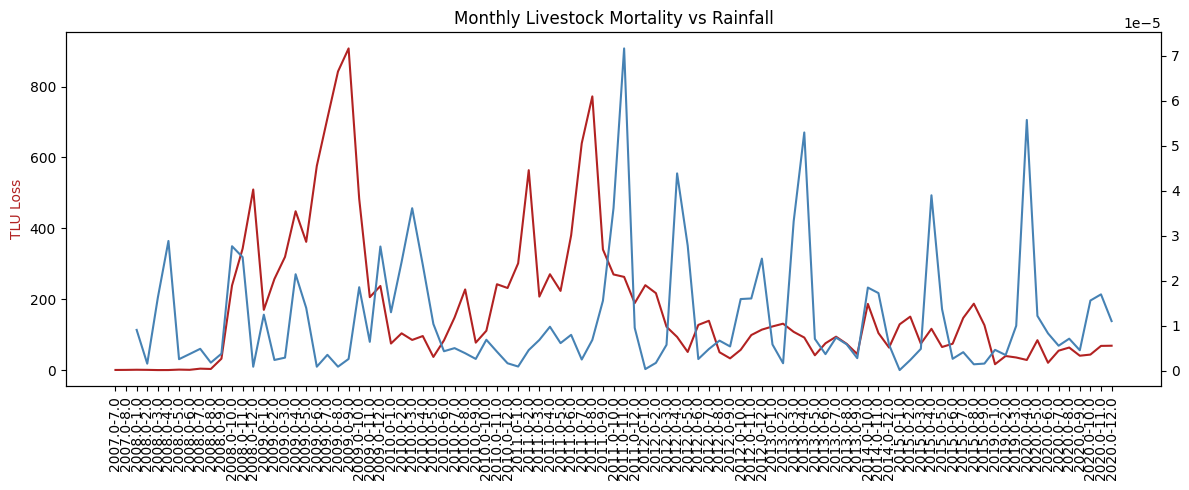

In [29]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(data["year"].astype(str) + "-" + data["month"].astype(str),
         data["tlu_loss"], color="firebrick", label="TLU Loss")
ax1.set_ylabel("TLU Loss", color="firebrick")

ax2 = ax1.twinx()
ax2.plot(data["year"].astype(str) + "-" + data["month"].astype(str),
         data["Rainf_tavg"], color="steelblue", label="Rainfall")

ax1.set_title("Monthly Livestock Mortality vs Rainfall")
ax1.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()


In [30]:
for lag in [1, 3, 6]:
    data[f"rain_lag_{lag}"] = data["Rainf_tavg"].shift(lag)
    data[f"soil_lag_{lag}"] = data["SoilMoi10_40cm_inst"].shift(lag)


In [31]:
corrs = []

for lag in [0, 1, 3, 6]:
    corrs.append({
        "lag_months": lag,
        "rain_corr": data["tlu_loss"].corr(data[f"rain_lag_{lag}"] if lag > 0 else data["Rainf_tavg"]),
        "soil_corr": data["tlu_loss"].corr(data[f"soil_lag_{lag}"] if lag > 0 else data["SoilMoi10_40cm_inst"])
    })

pd.DataFrame(corrs)


,lag_months,rain_corr,soil_corr
0,0,-0.117375,-0.410605
1,1,-0.159429,-0.415310
2,3,-0.096107,-0.340840
3,6,-0.200581,-0.227451


In [32]:
data["rain_bin"] = pd.qcut(
    data["Rainf_tavg"],
    q=5,
    duplicates="drop"
)

data.groupby("rain_bin")["tlu_loss"].mean()


/var/folders/m6/t8891b6n387709tqj500t0z00000gn/T/ipykernel_92945/3582804744.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("rain_bin")["tlu_loss"].mean()


rain_bin
(-0.000999833, 2.64e-06]    293.626316
(2.64e-06, 4.89e-06]        161.661111
(4.89e-06, 8.48e-06]        147.010526
(8.48e-06, 1.8e-05]         115.005556
(1.8e-05, 7.17e-05]         176.710526
Name: tlu_loss, dtype: float64

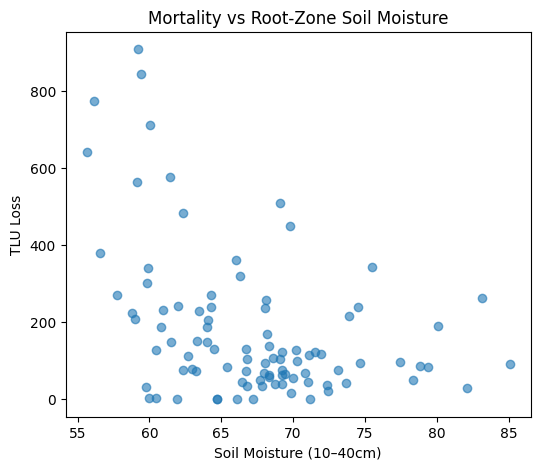

In [33]:
plt.figure(figsize=(6, 5))
plt.scatter(
    data["SoilMoi10_40cm_inst"],
    data["tlu_loss"],
    alpha=0.6
)
plt.xlabel("Soil Moisture (10–40cm)")
plt.ylabel("TLU Loss")
plt.title("Mortality vs Root-Zone Soil Moisture")
plt.show()


In [34]:
data["dry_signal"] = (
    (data["Rainf_tavg"] < data["Rainf_tavg"].quantile(0.2)) &
    (data["SoilMoi10_40cm_inst"] < data["SoilMoi10_40cm_inst"].quantile(0.2))
)

data.groupby("dry_signal")["tlu_loss"].mean()


dry_signal
False    149.937209
True     423.977778
Name: tlu_loss, dtype: float64